# OMSCS 2026 Poster Figures — HAAG Spatial Camera-Trap

Renders every candidate figure (V1–V14) for the 24×36" portrait poster built by [poster/make_poster.py](poster/make_poster.py). Outputs land in [figures/poster/svg/](figures/poster/svg/) (primary, drop into PPTX via Insert → Picture) and [figures/poster/png/](figures/poster/png/) (600 dpi fallback). All figures use the *Field Guide* palette defined in [poster/palette.py](poster/palette.py) with a **transparent** background so the poster's PAPER `#F6EFD8` shows through seamlessly.

Three abstract claims drive the figure design:
1. **Empirical vs predicted biodiversity** (V1–V5)
2. **Data completeness + community stability** (V6–V9)
3. **Ecological change** (V10–V13)


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from poster.palette import (
    CATEGORICAL, CLAY, FOG, FOREST, INDIGO, IRON, MPL_RCPARAMS,
    PAPER, PARCHMENT, SKY, STONE, STRAW, TERRACOTTA,
)

mpl.rcParams.update(MPL_RCPARAMS)
mpl.rcParams["svg.fonttype"] = "path"
mpl.rcParams["svg.hashsalt"] = "omscs2026"
mpl.rcParams["figure.facecolor"] = "none"
mpl.rcParams["axes.facecolor"] = "none"
mpl.rcParams["savefig.facecolor"] = "none"
mpl.rcParams["savefig.transparent"] = True
mpl.rcParams["figure.constrained_layout.use"] = True

SVG_DIR = Path("figures/poster/svg")
PNG_DIR = Path("figures/poster/png")
for d in (SVG_DIR, PNG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SLOT = {
    "hero":        (11.10, 8.10),
    "boxA":        (6.37, 4.90),
    "boxB":        (6.37, 4.90),
    "boxC":        (7.85, 2.75),
    "supporting":  (10.50, 3.40),
    "fieldplate":  (4.80, 2.60),
}

def savefig_slot(fig, slot_name: str, name: str):
    """Save at EXACT slot dimensions so aspect ratio matches poster placeholder."""
    w, h = SLOT[slot_name]
    fig.set_size_inches(w, h)
    # No bbox_inches='tight' — that crops below slot size. Keep full figure.
    fig.savefig(SVG_DIR / f"{name}.svg", transparent=True)
    fig.savefig(PNG_DIR / f"{name}.png", dpi=600, transparent=True)
    print(f"  saved {name}: {slot_name} slot {w}x{h}in")


## Data load

In [2]:
# Load ONLY columns we actually use — cuts SSUSA footprint roughly in half
SSUSA_COLS = [
    "Year", "Camera_Trap_Array", "Deployment_ID",
    "Species_Name", "Above_Threshold", "Body_Mass_g",
    "Latitude", "Longitude", "Habitat", "Development_Level",
]
ssusa = pd.read_csv("cleaned/ssusa_cleaned.csv", usecols=SSUSA_COLS,
                    low_memory=False)
iucn_shp = gpd.read_file("cleaned/iucn_cleaned.shp").to_crs("EPSG:5070")

array_fp = gpd.read_file("preprocessed_data/ssusa_array_footprints_1km.geojson")
camera_fp = gpd.read_file("preprocessed_data/ssusa_camera_footprints_1km.geojson")
assert array_fp.crs.to_epsg() == 5070 and camera_fp.crs.to_epsg() == 5070

iucn_array_lk = pd.read_csv("preprocessed_data/iucn_array_species_lookup_1km.csv")
iucn_camera_lk = pd.read_csv("preprocessed_data/iucn_camera_species_lookup_1km.csv")

print("SSUSA rows:", len(ssusa))
print("IUCN polygons:", len(iucn_shp))
print("Array footprints:", len(array_fp))
print("Camera footprints:", len(camera_fp))
print("IUCN array lookup rows:", len(iucn_array_lk))


SSUSA rows: 713319
IUCN polygons: 733
Array footprints: 262
Camera footprints: 7340
IUCN array lookup rows: 11927


In [3]:
# --- Derive per-array observed vs predicted species sets (mass-threshold filtered) ---
obs = (ssusa.loc[ssusa["Above_Threshold"] == True,
                 ["Camera_Trap_Array", "Species_Name", "Year"]]
             .dropna(subset=["Species_Name", "Camera_Trap_Array"])
             .rename(columns={"Species_Name": "sci_name"})
             .drop_duplicates())

pred = (iucn_array_lk.loc[iucn_array_lk["ab_thres"] == True,
                          ["Camera_Trap_Array", "sci_name"]]
                     .drop_duplicates())

obs_sets  = obs.groupby("Camera_Trap_Array")["sci_name"].apply(set)
pred_sets = pred.groupby("Camera_Trap_Array")["sci_name"].apply(set)

arrays = sorted(set(obs_sets.index) | set(pred_sets.index))
rows = []
for a in arrays:
    o = obs_sets.get(a, set())
    p = pred_sets.get(a, set())
    inter = len(o & p)
    union = len(o | p)
    rows.append({
        "Camera_Trap_Array": a,
        "n_observed": len(o),
        "n_predicted": len(p),
        "n_intersect": inter,
        "n_missed": len(p - o),
        "n_extra": len(o - p),
        "jaccard": inter / union if union else np.nan,
    })
array_agreement = pd.DataFrame(rows)

array_gdf = array_fp.merge(array_agreement, on="Camera_Trap_Array", how="left")
print(array_agreement.describe()[["n_observed", "n_predicted", "jaccard"]])


       n_observed  n_predicted     jaccard
count  262.000000    262.00000  262.000000
mean     9.916031     15.51145    0.558276
std      2.832591      4.28553    0.186007
min      1.000000      0.00000    0.000000
25%      8.000000     13.00000    0.467647
50%     10.000000     15.00000    0.578947
75%     11.000000     18.00000    0.666667
max     21.000000     27.00000    1.000000


In [4]:
# --- Reusable colormaps built from palette tokens ---
CMAP_OBSERVED  = LinearSegmentedColormap.from_list("fg_obs",  [PAPER, INDIGO])
CMAP_PREDICTED = LinearSegmentedColormap.from_list("fg_pred", [PAPER, TERRACOTTA])
CMAP_AGREE     = LinearSegmentedColormap.from_list("fg_agree",
                    [TERRACOTTA, PAPER, INDIGO])

# CONUS bounds in EPSG:5070 for consistent map extents
CONUS_XLIM = (-2.5e6, 2.6e6)
CONUS_YLIM = (2.5e5, 3.3e6)

# --- US basemap: Natural Earth 50m admin-1 states (public domain) ---
US_STATES_PATH = "data/basemap/ne_50m_admin_1_states_provinces.shp"
_us = gpd.read_file(US_STATES_PATH)
US_STATES = _us[(_us["admin"] == "United States of America") &
                (~_us["name"].isin(["Alaska", "Hawaii"]))].to_crs("EPSG:5070")

def draw_us_basemap(ax, *, fill=None, edge=None, lw=0.4, alpha=1.0):
    """Draw CONUS state outlines styled with Field Guide palette.

    Default: transparent fill so poster PAPER shows through, STONE-colored edges
    at a weight light enough to let foreground choropleths dominate.
    """
    US_STATES.plot(
        ax=ax,
        facecolor=(fill if fill is not None else "none"),
        edgecolor=(edge if edge is not None else STONE),
        linewidth=lw,
        alpha=alpha,
        zorder=0,
    )

def _strip_map_axes(ax):
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(*CONUS_XLIM); ax.set_ylim(*CONUS_YLIM)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.grid(False)


## V1 — HERO · Agreement choropleth (Jaccard per array)
Diverging ramp TERRACOTTA → PAPER → INDIGO, centered at Jaccard = 0.5. Arrays with more predicted-but-absent species drift TERRACOTTA; arrays with strong agreement drift INDIGO.

  saved V1_hero_agreement_jaccard: hero slot 11.1x8.1in


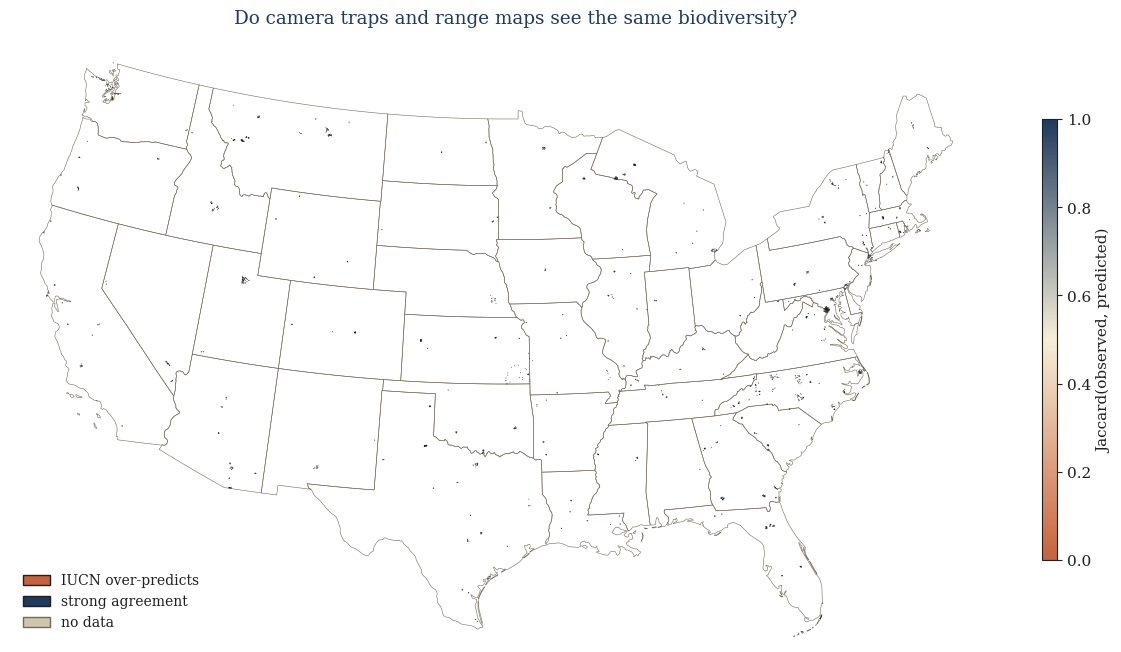

In [5]:
fig, ax = plt.subplots()

draw_us_basemap(ax, lw=0.4)

norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1.0)
array_gdf.plot(column="jaccard", cmap=CMAP_AGREE, norm=norm,
               edgecolor=IRON, linewidth=0.3, ax=ax,
               missing_kwds={"color": FOG, "edgecolor": STONE, "linewidth": 0.2},
               zorder=2)
_strip_map_axes(ax)
ax.set_title("Do camera traps and range maps see the same biodiversity?",
             color=INDIGO, pad=10)

sm = plt.cm.ScalarMappable(cmap=CMAP_AGREE, norm=norm)
cb = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02, aspect=28)
cb.set_label("Jaccard(observed, predicted)", color=IRON)
cb.outline.set_edgecolor(IRON)
cb.ax.tick_params(colors=IRON)

legend_elts = [
    Patch(facecolor=TERRACOTTA, edgecolor=IRON, label="IUCN over-predicts"),
    Patch(facecolor=INDIGO,     edgecolor=IRON, label="strong agreement"),
    Patch(facecolor=FOG,        edgecolor=STONE, label="no data"),
]
ax.legend(handles=legend_elts, loc="lower left", frameon=False,
          labelcolor=IRON, fontsize=10)

savefig_slot(fig, "hero", "V1_hero_agreement_jaccard")
plt.show()


## V2 — HERO alt · 4-panel comparison (observed · predicted · intersect · gap)

  saved V2_hero_4panel_comparison: hero slot 11.1x8.1in


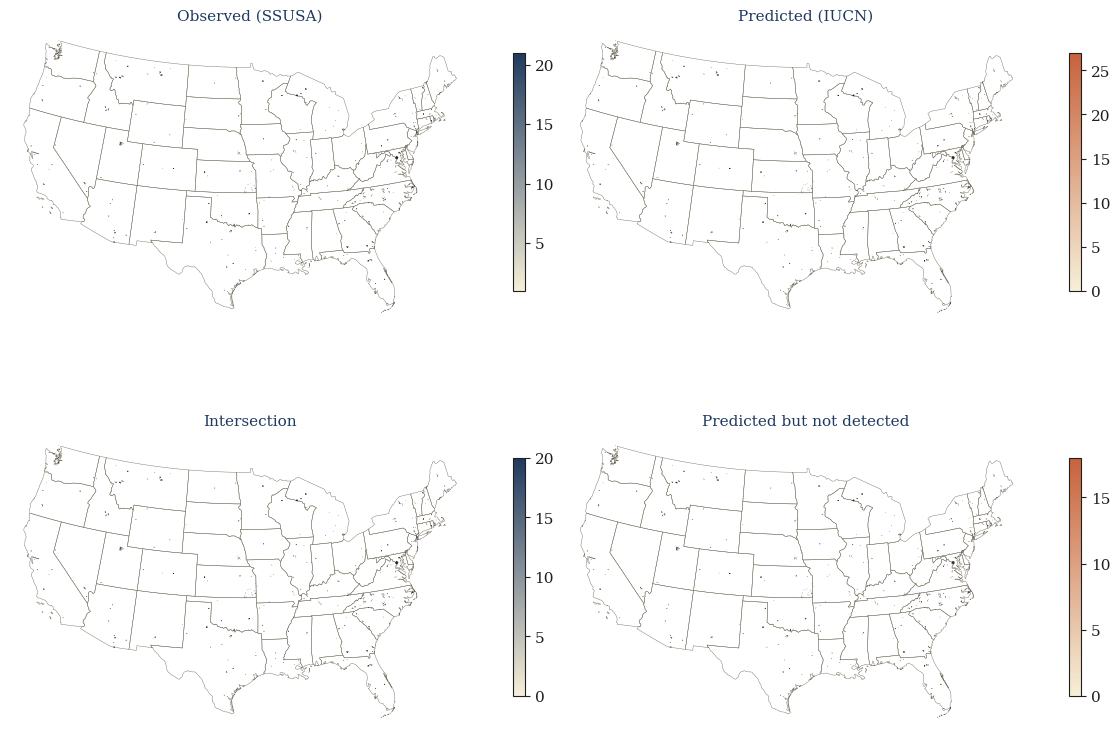

In [6]:
fig, axes = plt.subplots(2, 2, constrained_layout=True)
panels = [
    ("n_observed",  CMAP_OBSERVED,  "Observed (SSUSA)"),
    ("n_predicted", CMAP_PREDICTED, "Predicted (IUCN)"),
    ("n_intersect", CMAP_OBSERVED,  "Intersection"),
    ("n_missed",    CMAP_PREDICTED, "Predicted but not detected"),
]
for ax, (col, cmap, title) in zip(axes.ravel(), panels):
    draw_us_basemap(ax, lw=0.3)
    array_gdf.plot(column=col, cmap=cmap, edgecolor=IRON, linewidth=0.2, ax=ax,
                   legend=True, legend_kwds={"shrink": 0.6},
                   missing_kwds={"color": FOG, "edgecolor": STONE, "linewidth": 0.1},
                   zorder=2)
    _strip_map_axes(ax)
    ax.set_title(title, color=INDIGO, fontsize=11)

savefig_slot(fig, "hero", "V2_hero_4panel_comparison")
plt.show()


## V3 — Supporting · Per-species predicted-vs-observed scatter

  saved V3_supporting_species_scatter: supporting slot 10.5x3.4in


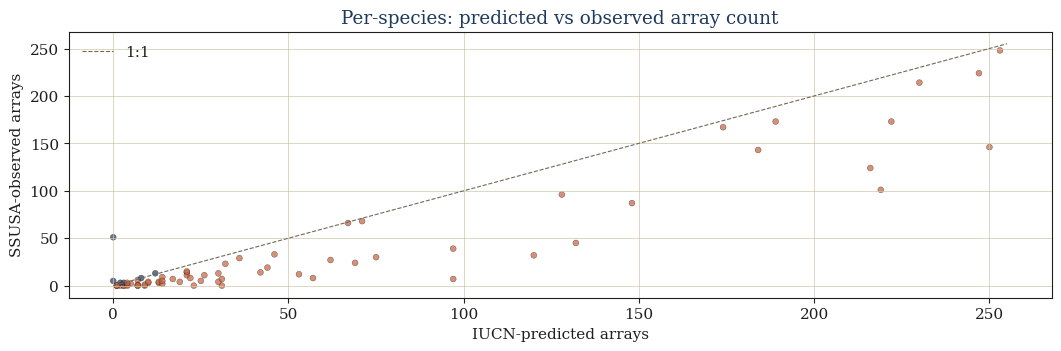

In [7]:
pred_by_sp = pred.groupby("sci_name")["Camera_Trap_Array"].nunique().rename("predicted")
obs_by_sp  = obs.groupby("sci_name")["Camera_Trap_Array"].nunique().rename("observed")
sp = pd.concat([pred_by_sp, obs_by_sp], axis=1).fillna(0).astype(int)
sp["diff"] = sp["observed"] - sp["predicted"]

fig, ax = plt.subplots()
ax.scatter(sp["predicted"], sp["observed"],
           c=[INDIGO if d >= 0 else TERRACOTTA for d in sp["diff"]],
           s=18, alpha=0.7, edgecolor=IRON, linewidth=0.3)
mx = max(sp["predicted"].max(), sp["observed"].max()) + 2
ax.plot([0, mx], [0, mx], color=STONE, linestyle="--", linewidth=0.8, label="1:1")
ax.set_xlabel("IUCN-predicted arrays", color=IRON)
ax.set_ylabel("SSUSA-observed arrays", color=IRON)
ax.set_title("Per-species: predicted vs observed array count", color=INDIGO)
ax.legend(frameon=False, labelcolor=IRON)
savefig_slot(fig, "supporting", "V3_supporting_species_scatter")
plt.show()


## V4 — Supporting · Top-20 discordant species

  saved V4_supporting_top_discordance: supporting slot 10.5x3.4in


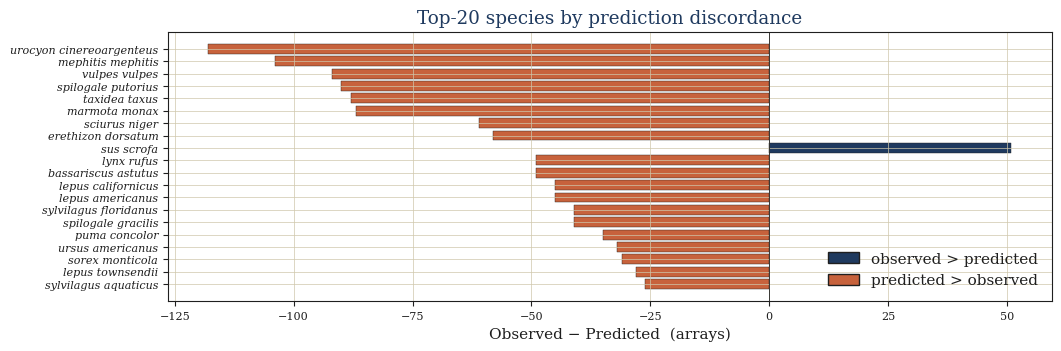

In [8]:
top = sp.reindex(sp["diff"].abs().sort_values(ascending=False).index).head(20).iloc[::-1]

fig, ax = plt.subplots()
colors = [INDIGO if d >= 0 else TERRACOTTA for d in top["diff"]]
ax.barh(top.index, top["diff"], color=colors, edgecolor=IRON, linewidth=0.3)
ax.axvline(0, color=IRON, linewidth=0.6)
ax.set_xlabel("Observed − Predicted  (arrays)", color=IRON)
ax.set_title("Top-20 species by prediction discordance", color=INDIGO)
ax.tick_params(labelsize=8)
for lbl in ax.get_yticklabels():
    lbl.set_style("italic")
legend_elts = [
    Patch(facecolor=INDIGO, edgecolor=IRON, label="observed > predicted"),
    Patch(facecolor=TERRACOTTA, edgecolor=IRON, label="predicted > observed"),
]
ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON, loc="lower right")
savefig_slot(fig, "supporting", "V4_supporting_top_discordance")
plt.show()


## V5 — Field plate · Single-species drill-down

  saved V5_fieldplate_flagship_drilldown: fieldplate slot 4.8x2.6in


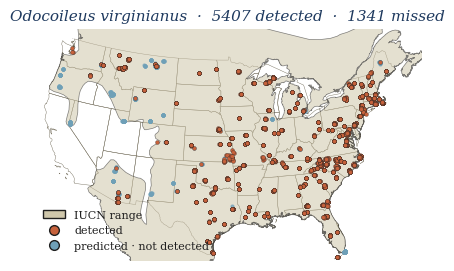

In [9]:
FLAGSHIP = "Odocoileus virginianus"

# IUCN polygon for the species (for the range outline)
poly = iucn_shp[iucn_shp["sci_name"].str.lower() == FLAGSHIP.lower()]

# Cameras where the species was detected in SSUSA
detected = ssusa.loc[(ssusa["Species_Name"].str.lower() == FLAGSHIP.lower()) &
                     (ssusa["Above_Threshold"] == True),
                     ["Longitude", "Latitude"]].drop_duplicates()
detected_gdf = gpd.GeoDataFrame(
    detected,
    geometry=gpd.points_from_xy(detected["Longitude"], detected["Latitude"]),
    crs="EPSG:4326",
).to_crs("EPSG:5070")

# Cameras IUCN predicts as in-range for this species (above mass threshold)
pred_cam_ids = set(iucn_camera_lk.loc[
    (iucn_camera_lk["sci_name"].str.lower() == FLAGSHIP.lower()) &
    (iucn_camera_lk["ab_thres"] == True),
    "camera_fp_id"
])

# Camera centroids for plotting
cam_pts = camera_fp.copy()
cam_pts["geometry"] = cam_pts.geometry.centroid

# "Missed" = predicted-in-range cameras whose coords are NOT in the detected set
detected_xy = set(zip(detected["Longitude"].round(5), detected["Latitude"].round(5)))
pred_in_range = cam_pts[cam_pts["camera_fp_id"].isin(pred_cam_ids)].copy()
missed_mask = ~pred_in_range.apply(
    lambda r: (round(r["Longitude"], 5), round(r["Latitude"], 5)) in detected_xy,
    axis=1,
) if len(pred_in_range) else pd.Series([], dtype=bool)
in_range = pred_in_range[missed_mask] if len(pred_in_range) else pred_in_range

fig, ax = plt.subplots()
draw_us_basemap(ax, lw=0.3)
if not poly.empty:
    poly.plot(ax=ax, facecolor=FOG, edgecolor=IRON, linewidth=0.5, alpha=0.55,
              zorder=2)
if len(in_range):
    in_range.plot(ax=ax, color=SKY, markersize=4, alpha=0.7, zorder=3)
detected_gdf.plot(ax=ax, color=TERRACOTTA, markersize=8,
                  edgecolor=IRON, linewidth=0.2, zorder=4)
_strip_map_axes(ax)
ax.set_title(f"{FLAGSHIP}  ·  {len(detected_gdf)} detected  ·  {len(in_range)} missed",
             color=INDIGO, fontsize=11, style="italic")
legend_elts = [
    Patch(facecolor=FOG, edgecolor=IRON, label="IUCN range"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=TERRACOTTA,
           markeredgecolor=IRON, markersize=7, label="detected"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=SKY,
           markeredgecolor=IRON, markersize=7, label="predicted · not detected"),
]
ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
          loc="lower left", fontsize=8)
savefig_slot(fig, "fieldplate", "V5_fieldplate_flagship_drilldown")
plt.show()


## V6 — Box A · Species Accumulation Curves by body-mass stratum

  saved V6_boxA_sac_by_mass: boxA slot 6.37x4.9in


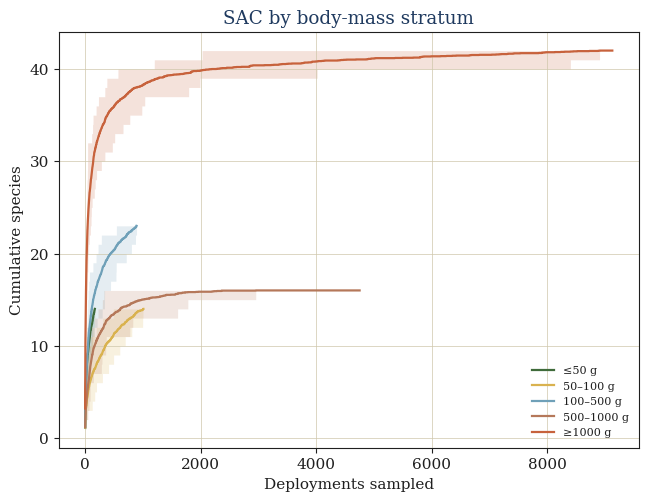

In [10]:
# Rarefaction-style SAC: randomly order deployments, count unique species seen so far.
# One curve per body-mass stratum.
STRATA = [
    ("\u226450 g",      0,   50,   FOREST),
    ("50\u2013100 g",   50,  100,  STRAW),
    ("100\u2013500 g",  100, 500,  SKY),
    ("500\u20131000 g", 500, 1000, CLAY),
    ("\u22651000 g",    1000, np.inf, TERRACOTTA),
]

fig, ax = plt.subplots()
rng = np.random.default_rng(20260512)
for label, lo, hi, color in STRATA:
    sub = ssusa[(ssusa["Body_Mass_g"] >= lo) & (ssusa["Body_Mass_g"] < hi)]
    deployments = sub[["Deployment_ID", "Species_Name"]].dropna()
    if deployments.empty:
        continue
    all_ids = deployments["Deployment_ID"].unique()
    N_REP = 50
    all_curves = []
    for _ in range(N_REP):
        order = rng.permutation(all_ids)
        seen = set()
        curve = []
        id_to_sp = deployments.groupby("Deployment_ID")["Species_Name"].apply(set)
        for d in order:
            seen |= id_to_sp.get(d, set())
            curve.append(len(seen))
        all_curves.append(curve)
    arr = np.array(all_curves)
    mean = arr.mean(axis=0); lo_, hi_ = arr.min(axis=0), arr.max(axis=0)
    x = np.arange(1, arr.shape[1] + 1)
    ax.fill_between(x, lo_, hi_, color=color, alpha=0.18, linewidth=0)
    ax.plot(x, mean, color=color, linewidth=1.6, label=label)

ax.set_xlabel("Deployments sampled", color=IRON)
ax.set_ylabel("Cumulative species", color=IRON)
ax.set_title("SAC by body-mass stratum", color=INDIGO)
ax.legend(frameon=False, labelcolor=IRON, fontsize=8, loc="lower right")
savefig_slot(fig, "boxA", "V6_boxA_sac_by_mass")
plt.show()


## R1 — Box A · SAC · IUCN (predicted) vs SSUSA (observed), ≥ 500 g
Rarefaction-style species accumulation at the **array** level, restricted to mammals with adult body mass ≥ 500 g.

- **SSUSA (observed)** — unique species detected above threshold across arrays sampled so far.
- **IUCN (predicted)** — unique species IUCN *predicts* in-range at those same arrays (ceiling).

Same random array ordering is used for both lines so they're directly comparable; the shaded band is the min–max envelope over 200 random permutations. The gap between the two lines *is* the headline story.

arrays: 262   ssusa≥500g species total: 58   iucn≥500g species total: 64


  saved R1_boxA_sac_iucn_vs_ssusa_500g: boxA slot 6.37x4.9in


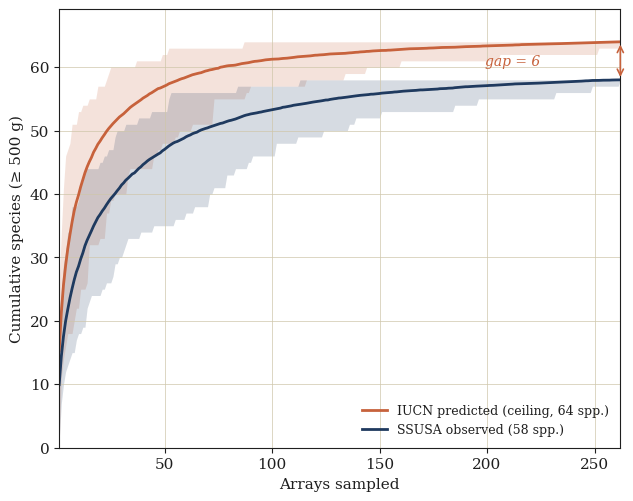

In [11]:
# --- Species body-mass lookup: COMBINE traits + SSUSA fallback ---
traits = pd.read_csv("data/COMBINE/trait_data_imputed.csv",
                     usecols=["iucn2020_binomial", "adult_mass_g"])
traits["sci_key"] = traits["iucn2020_binomial"].str.lower().str.strip()
mass_lookup = traits.groupby("sci_key")["adult_mass_g"].mean()

ssusa_mass_lookup = (ssusa.dropna(subset=["Species_Name", "Body_Mass_g"])
                          .assign(sci_key=lambda d: d["Species_Name"].str.lower().str.strip())
                          .groupby("sci_key")["Body_Mass_g"].mean())
mass_lookup = ssusa_mass_lookup.combine_first(mass_lookup)

MASS_THRESH_G = 500.0

# --- SSUSA: arrays -> set of ≥500g species observed above threshold ---
ssusa_heavy = ssusa[(ssusa["Above_Threshold"] == True) &
                    (ssusa["Body_Mass_g"] >= MASS_THRESH_G)].dropna(
    subset=["Camera_Trap_Array", "Species_Name"])
ssusa_by_array = (ssusa_heavy.groupby("Camera_Trap_Array")["Species_Name"]
                  .apply(lambda s: set(s.unique())))

# --- IUCN: arrays -> set of ≥500g species predicted in-range ---
iucn_lk_mass = iucn_array_lk.copy()
iucn_lk_mass["sci_key"] = iucn_lk_mass["sci_name"].str.lower().str.strip()
iucn_lk_mass["mass_g"] = iucn_lk_mass["sci_key"].map(mass_lookup)
iucn_heavy = iucn_lk_mass[(iucn_lk_mass["mass_g"] >= MASS_THRESH_G)].dropna(
    subset=["Camera_Trap_Array", "sci_name"])
iucn_by_array = (iucn_heavy.groupby("Camera_Trap_Array")["sci_name"]
                 .apply(lambda s: set(s.unique())))

arrays_all = sorted(set(ssusa_by_array.index) | set(iucn_by_array.index))
print(f"arrays: {len(arrays_all)}   ssusa≥500g species total: "
      f"{len(set.union(*ssusa_by_array.values)) if len(ssusa_by_array) else 0}   "
      f"iucn≥500g species total: "
      f"{len(set.union(*iucn_by_array.values)) if len(iucn_by_array) else 0}")

# --- Rarefaction: SAME random array order for both curves ---
N_REP = 200
rng = np.random.default_rng(20260512)
N = len(arrays_all)
ssusa_curves = np.zeros((N_REP, N), dtype=int)
iucn_curves  = np.zeros((N_REP, N), dtype=int)
for r in range(N_REP):
    order = rng.permutation(arrays_all)
    s_seen, i_seen = set(), set()
    for k, a in enumerate(order):
        s_seen |= ssusa_by_array.get(a, set())
        i_seen |= iucn_by_array.get(a, set())
        ssusa_curves[r, k] = len(s_seen)
        iucn_curves[r, k]  = len(i_seen)

x = np.arange(1, N + 1)
s_mean, s_lo, s_hi = ssusa_curves.mean(0), ssusa_curves.min(0), ssusa_curves.max(0)
i_mean, i_lo, i_hi = iucn_curves.mean(0),  iucn_curves.min(0),  iucn_curves.max(0)

fig, ax = plt.subplots()
ax.fill_between(x, i_lo, i_hi, color=TERRACOTTA, alpha=0.18, linewidth=0)
ax.fill_between(x, s_lo, s_hi, color=INDIGO,     alpha=0.18, linewidth=0)
ax.plot(x, i_mean, color=TERRACOTTA, linewidth=2.0,
        label=f"IUCN predicted (ceiling, {i_mean[-1]:.0f} spp.)")
ax.plot(x, s_mean, color=INDIGO,     linewidth=2.0,
        label=f"SSUSA observed ({s_mean[-1]:.0f} spp.)")

# Shade the final gap for emphasis
gap = i_mean[-1] - s_mean[-1]
ax.annotate(
    f"gap = {gap:.0f}", xy=(x[-1], (i_mean[-1] + s_mean[-1]) / 2),
    xytext=(-58, 0), textcoords="offset points",
    ha="right", va="center", color=TERRACOTTA, fontsize=10, style="italic",
)
ax.annotate(
    "", xy=(x[-1], i_mean[-1]), xytext=(x[-1], s_mean[-1]),
    arrowprops=dict(arrowstyle="<->", color=TERRACOTTA, linewidth=1.2),
)

ax.set_xlabel("Arrays sampled", color=IRON)
ax.set_ylabel("Cumulative species (≥ 500 g)", color=IRON)
ax.legend(frameon=False, labelcolor=IRON, fontsize=9, loc="lower right")
ax.set_xlim(1, N)
ax.set_ylim(0, max(i_hi.max(), s_hi.max()) * 1.08)
savefig_slot(fig, "boxA", "R1_boxA_sac_iucn_vs_ssusa_500g")
plt.show()


## V7 — Box B · CI-gap vs sampling effort
Binomial upper-bound on "unseen species" as deployments accumulate. For each array we estimate the probability that at least one predicted species remains undetected after *n* deployments. Uses a simple 1 − (1 − p̂)^n envelope where p̂ = detected fraction.

  saved V7_boxB_ci_gap_by_effort: boxB slot 6.37x4.9in


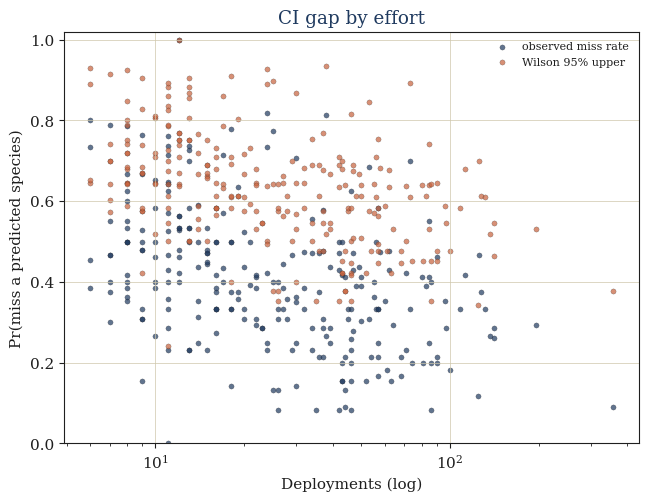

In [12]:
obs_per_array = obs.groupby(["Camera_Trap_Array", "sci_name"]).size().reset_index(name="n_det")
effort = ssusa.groupby("Camera_Trap_Array")["Deployment_ID"].nunique().rename("n_deploy")

def _wilson_upper(k, n, z=1.96):
    """Two-sided 95% Wilson upper bound for proportion k/n (numpy-only)."""
    if n == 0:
        return 1.0
    phat = k / n
    denom = 1 + z * z / n
    center = (phat + z * z / (2 * n)) / denom
    margin = (z / denom) * np.sqrt(phat * (1 - phat) / n + z * z / (4 * n * n))
    return min(1.0, center + margin)

fig, ax = plt.subplots()
rows = []
for a, n_dep in effort.items():
    p = pred_sets.get(a, set()); o = obs_sets.get(a, set())
    if not p or n_dep < 2:
        continue
    missed = len(p - o); total = len(p)
    p_miss_hat = missed / total
    upper = _wilson_upper(missed, total)
    rows.append((n_dep, p_miss_hat, upper))
rows = np.array(sorted(rows))

ax.scatter(rows[:, 0], rows[:, 1], color=INDIGO, s=14, alpha=0.7,
           edgecolor=IRON, linewidth=0.2, label="observed miss rate")
ax.scatter(rows[:, 0], rows[:, 2], color=TERRACOTTA, s=14, alpha=0.7,
           edgecolor=IRON, linewidth=0.2, label="Wilson 95% upper")
ax.set_xscale("log")
ax.set_xlabel("Deployments (log)", color=IRON)
ax.set_ylabel("Pr(miss a predicted species)", color=IRON)
ax.set_title("CI gap by effort", color=INDIGO)
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, labelcolor=IRON, fontsize=8, loc="upper right")
savefig_slot(fig, "boxB", "V7_boxB_ci_gap_by_effort")
plt.show()


## V10 — Box C headline · False-plateau matrix (array × year)
Each cell = array-year. 2×2 classification on (SAC slope ≈ 0?) × (predicted-but-not-detected > 0?):
- **INDIGO** · SAC plateau + no IUCN gap → *true completeness*
- **TERRACOTTA** · SAC plateau + IUCN gap → ***false plateau*** (the headline)
- **SKY** · SAC still rising + no IUCN gap → *still accumulating*
- **FOG** · SAC still rising + IUCN gap → *early survey*

  saved V10_boxC_false_plateau_matrix: boxC slot 7.85x2.75in


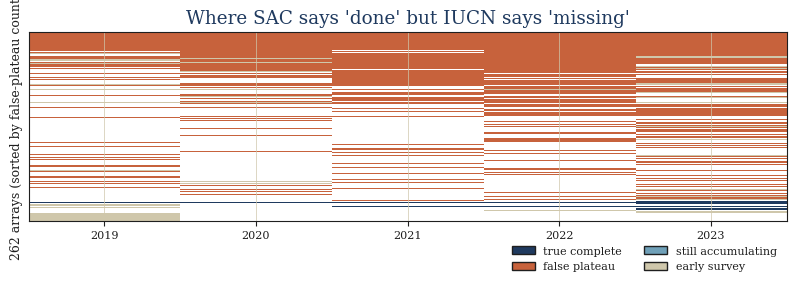

In [13]:
# Build array×year panel
obs_ay = (ssusa.loc[ssusa["Above_Threshold"] == True,
                    ["Camera_Trap_Array", "Year", "Species_Name", "Deployment_ID"]]
                .dropna())

def _cls(arr, yr):
    sub = obs_ay[(obs_ay["Camera_Trap_Array"] == arr) & (obs_ay["Year"] == yr)]
    if sub.empty: return np.nan
    # SAC slope proxy: new species per deployment over last 20% of effort
    deps = sub["Deployment_ID"].dropna().unique()
    if len(deps) < 5: return np.nan
    id_to_sp = sub.groupby("Deployment_ID")["Species_Name"].apply(set)
    seen = set(); curve = []
    for d in deps:
        seen |= id_to_sp.get(d, set()); curve.append(len(seen))
    curve = np.array(curve)
    tail_n = max(2, len(curve) // 5)
    tail_slope = (curve[-1] - curve[-tail_n]) / tail_n
    plateau = tail_slope < 0.1
    predicted = pred_sets.get(arr, set())
    gap = len(predicted - set(sub["Species_Name"])) > 0
    if plateau and gap:       return 1  # false plateau
    if plateau and not gap:   return 0  # true complete
    if not plateau and gap:   return 3  # early survey
    return 2                             # still accumulating

years = sorted(obs_ay["Year"].dropna().astype(int).unique())
arrays_with_data = sorted(obs_ay["Camera_Trap_Array"].dropna().unique())
M = np.full((len(arrays_with_data), len(years)), np.nan)
for i, a in enumerate(arrays_with_data):
    for j, y in enumerate(years):
        M[i, j] = _cls(a, y)

fig, ax = plt.subplots()
# Sort arrays by # false-plateau years (descending) to make the pattern pop
fp_count = np.nansum(M == 1, axis=1)
order = np.argsort(-fp_count)
M_sorted = M[order]

from matplotlib.colors import ListedColormap, BoundaryNorm
cmap4 = ListedColormap([INDIGO, TERRACOTTA, SKY, FOG])
norm4 = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap4.N)
im = ax.imshow(M_sorted, aspect="auto", cmap=cmap4, norm=norm4,
               interpolation="nearest")
ax.set_xticks(range(len(years)))
ax.set_xticklabels([str(y) for y in years], fontsize=8, color=IRON)
ax.set_yticks([])
ax.set_ylabel(f"{len(arrays_with_data)} arrays (sorted by false-plateau count)",
              color=IRON, fontsize=9)
ax.set_title("Where SAC says 'done' but IUCN says 'missing'", color=INDIGO)
legend_elts = [
    Patch(facecolor=INDIGO, edgecolor=IRON, label="true complete"),
    Patch(facecolor=TERRACOTTA, edgecolor=IRON, label="false plateau"),
    Patch(facecolor=SKY, edgecolor=IRON, label="still accumulating"),
    Patch(facecolor=FOG, edgecolor=IRON, label="early survey"),
]
ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
          fontsize=8, ncol=2, loc="upper right",
          bbox_to_anchor=(1.0, -0.08))
savefig_slot(fig, "boxC", "V10_boxC_false_plateau_matrix")
plt.show()


## V11 — Supporting · Multi-year Jaccard trajectory by habitat

  saved V11_supporting_jaccard_trajectory: supporting slot 10.5x3.4in


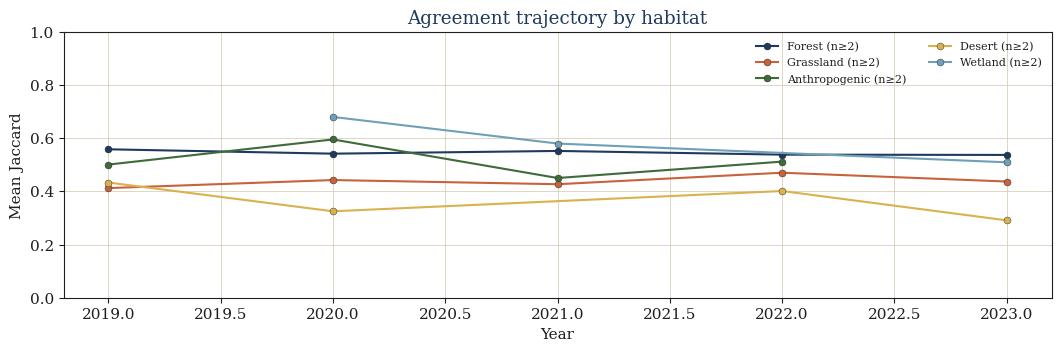

In [14]:
# Per (array, year, habitat) Jaccard vs IUCN prediction for that array
habitat_col = "Habitat"
ay = (ssusa.loc[ssusa["Above_Threshold"] == True,
                ["Camera_Trap_Array", "Year", "Species_Name", habitat_col]]
           .dropna(subset=["Camera_Trap_Array", "Year"]))

year_rows = []
for (arr, yr), grp in ay.groupby(["Camera_Trap_Array", "Year"]):
    o = set(grp["Species_Name"])
    p = pred_sets.get(arr, set())
    if not (o | p):
        continue
    j = len(o & p) / len(o | p)
    hb = grp[habitat_col].mode().iloc[0] if not grp[habitat_col].isna().all() else "Unknown"
    year_rows.append({"Year": int(yr), "jaccard": j, "habitat": hb})
ydf = pd.DataFrame(year_rows)

habitats = (ydf.groupby("habitat").size().sort_values(ascending=False).head(5).index.tolist())
PALETTE_CYC = [INDIGO, TERRACOTTA, FOREST, STRAW, SKY]

fig, ax = plt.subplots()
for h, color in zip(habitats, PALETTE_CYC):
    s = ydf[ydf["habitat"] == h].groupby("Year")["jaccard"].agg(["mean", "count"])
    s = s[s["count"] >= 2]
    ax.plot(s.index, s["mean"], color=color, marker="o", markersize=5,
            linewidth=1.5, label=f"{h} (n≥2)",
            markeredgecolor=IRON, markeredgewidth=0.3)
ax.set_xlabel("Year", color=IRON)
ax.set_ylabel("Mean Jaccard", color=IRON)
ax.set_title("Agreement trajectory by habitat", color=INDIGO)
ax.set_ylim(0, 1)
ax.legend(frameon=False, labelcolor=IRON, fontsize=8, ncol=2)
savefig_slot(fig, "supporting", "V11_supporting_jaccard_trajectory")
plt.show()


## Camera-level Jaccard + survey-night covariates
Shared preprocessing used by Box B variants (B2/B3), Box C (C1), and Supporting RF (S1).

In [15]:
# Build per-camera observed-species sets from SSUSA
# Use rounded (Lat, Lon) 5-digit as the camera key (matches iucn_camera_species_lookup_1km.csv)
ssusa["cam_key"] = (ssusa["Latitude"].round(5).astype(str)
                    + "_" + ssusa["Longitude"].round(5).astype(str))
ssusa_mass = ssusa[ssusa["Above_Threshold"] == True].copy()

obs_by_cam = (ssusa_mass.groupby("cam_key")["Species_Name"]
              .apply(lambda s: set(s.dropna()))
              .rename("obs_species"))

# Per-camera predicted set from IUCN lookup
iucn_camera_lk["cam_key"] = (iucn_camera_lk["Latitude"].round(5).astype(str)
                             + "_" + iucn_camera_lk["Longitude"].round(5).astype(str))
pred_by_cam = (iucn_camera_lk[iucn_camera_lk["ab_thres"] == True]
               .groupby("cam_key")["sci_name"]
               .apply(set).rename("pred_species"))

# Per-camera covariates: survey nights, habitat, development_level, array
cam_meta = (ssusa.groupby("cam_key")
            .agg(unique_nights=("Deployment_ID", "nunique"),
                 Camera_Trap_Array=("Camera_Trap_Array", "first"),
                 Habitat=("Habitat", lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
                 Development_Level=("Development_Level",
                                    lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
                 Latitude=("Latitude", "first"),
                 Longitude=("Longitude", "first")))

camera_compare = cam_meta.join(obs_by_cam, how="left").join(pred_by_cam, how="left")
camera_compare["obs_species"] = camera_compare["obs_species"].apply(
    lambda s: s if isinstance(s, set) else set())
camera_compare["pred_species"] = camera_compare["pred_species"].apply(
    lambda s: s if isinstance(s, set) else set())


def _jaccard(o, p):
    u = o | p
    return len(o & p) / len(u) if u else np.nan

camera_compare["jaccard_index"] = camera_compare.apply(
    lambda r: _jaccard(r["obs_species"], r["pred_species"]), axis=1)
camera_compare = camera_compare.dropna(subset=["jaccard_index"])
print(f"camera_compare rows: {len(camera_compare)}")
print(camera_compare["jaccard_index"].describe())

# Per-array: sum survey-nights, and array-level jaccard already in `array_agreement`
array_effort = (ssusa.groupby("Camera_Trap_Array")["Deployment_ID"]
                .nunique().rename("array_nights"))
array_jaccard = array_agreement.set_index("Camera_Trap_Array")[["jaccard"]].join(array_effort)
print(f"array_jaccard rows: {len(array_jaccard)}")


camera_compare rows: 7005
count    7005.000000
mean        0.251784
std         0.156016
min         0.000000
25%         0.130435
50%         0.230769
75%         0.357143
max         0.846154
Name: jaccard_index, dtype: float64


array_jaccard rows: 262


## H1 — HERO variant A · Out-of-range detections
Red dots for SSUSA detections whose coordinates fall OUTSIDE their species' IUCN polygon. Adapts John's point-in-polygon logic from the Archive notebook.

2304 out-of-range (camera, species) pairs out of 28323


  saved H1_hero_out_of_range: hero slot 11.1x8.1in


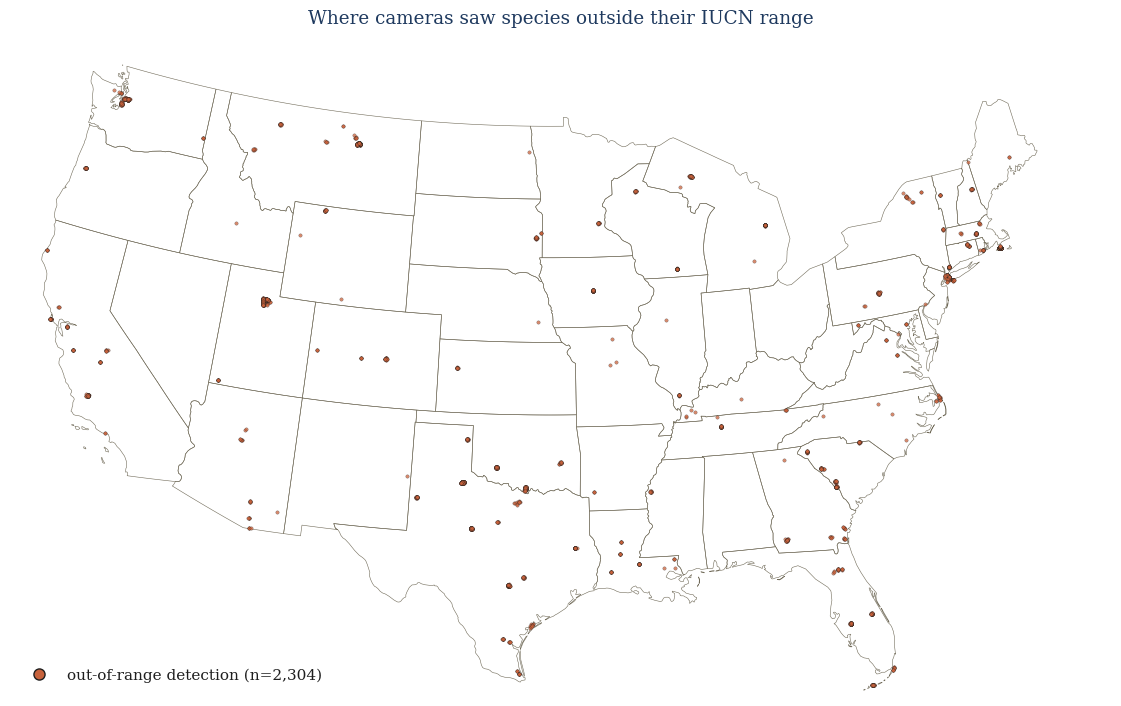

In [16]:
# Build unique (camera, species) detections and join to IUCN polygons
uniq_det = (ssusa_mass[["cam_key", "Latitude", "Longitude", "Species_Name"]]
            .drop_duplicates(subset=["cam_key", "Species_Name"])
            .dropna(subset=["Species_Name", "Latitude", "Longitude"]))
det_gdf = gpd.GeoDataFrame(
    uniq_det,
    geometry=gpd.points_from_xy(uniq_det["Longitude"], uniq_det["Latitude"]),
    crs="EPSG:4326",
).to_crs("EPSG:5070")

# Prepare IUCN by species for vectorized inside/outside test
iucn_by_sp = iucn_shp[["sci_name", "geometry"]].copy()
iucn_by_sp["sp_key"] = iucn_by_sp["sci_name"].str.lower()
det_gdf["sp_key"] = det_gdf["Species_Name"].str.lower()

# Left-join detections with matching IUCN polygons; if within -> inside, else outside
joined = gpd.sjoin(det_gdf, iucn_by_sp[["sp_key", "geometry"]], how="left",
                   predicate="within", lsuffix="det", rsuffix="iucn")
# A detection is "inside" if the joined sp_key_iucn matches sp_key_det
joined["inside"] = (joined["sp_key_det"] == joined["sp_key_iucn"])
# Collapse: keep at most one row per detection; mark inside if ANY matching polygon contained it
inside_any = joined.groupby(joined.index)["inside"].any()
det_gdf["inside"] = det_gdf.index.map(inside_any).fillna(False)

out_of_range = det_gdf[~det_gdf["inside"]]
print(f"{len(out_of_range)} out-of-range (camera, species) pairs out of {len(det_gdf)}")

fig, ax = plt.subplots()
draw_us_basemap(ax, lw=0.4)
out_of_range.plot(ax=ax, color=TERRACOTTA, markersize=6,
                  edgecolor=IRON, linewidth=0.2, alpha=0.75, zorder=3)
_strip_map_axes(ax)
ax.set_title("Where cameras saw species outside their IUCN range",
             color=INDIGO, pad=10)
legend_elts = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=TERRACOTTA,
           markeredgecolor=IRON, markersize=8,
           label=f"out-of-range detection (n={len(out_of_range):,})"),
]
ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
          loc="lower left", fontsize=11)
savefig_slot(fig, "hero", "H1_hero_out_of_range")
plt.show()


## H2 — HERO variant B · 5-km buffer sampling coverage
Union of 5-km buffers around all SSUSA detections, shaded on CONUS. Shows 'where the cameras actually sampled' as a spatial footprint.

  saved H2_hero_buffer_coverage: hero slot 11.1x8.1in


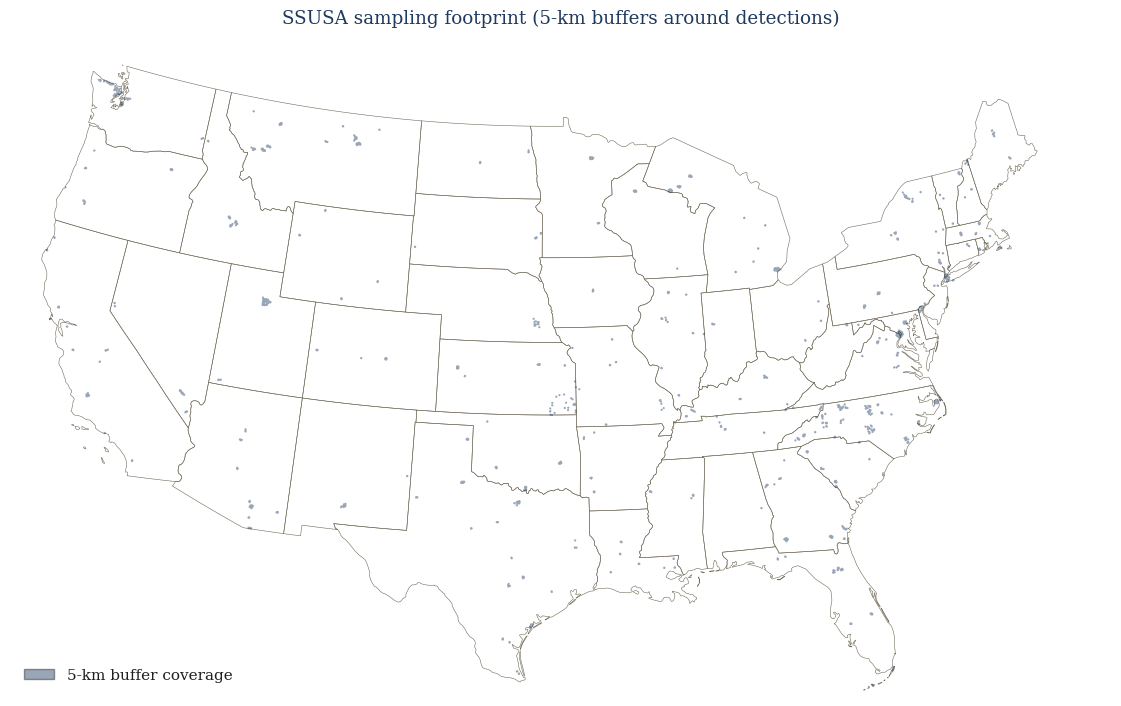

In [17]:
# 5 km buffer union of all unique detection points
buffer_union = det_gdf.geometry.buffer(5000).union_all()
buffer_gdf = gpd.GeoDataFrame(geometry=[buffer_union], crs="EPSG:5070")

fig, ax = plt.subplots()
draw_us_basemap(ax, lw=0.4)
buffer_gdf.plot(ax=ax, facecolor=INDIGO, edgecolor=INDIGO,
                linewidth=0.0, alpha=0.45, zorder=2)
_strip_map_axes(ax)
ax.set_title("SSUSA sampling footprint (5-km buffers around detections)",
             color=INDIGO, pad=10)
legend_elts = [
    Patch(facecolor=INDIGO, edgecolor=IRON, alpha=0.45,
          label="5-km buffer coverage"),
]
ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
          loc="lower left", fontsize=11)
savefig_slot(fig, "hero", "H2_hero_buffer_coverage")
plt.show()


## H3 — HERO variant C · Combined layers
FOG-filled aggregate IUCN union backdrop + INDIGO 5-km buffer coverage + TERRACOTTA out-of-range dots.

  saved H3_hero_combined: hero slot 11.1x8.1in


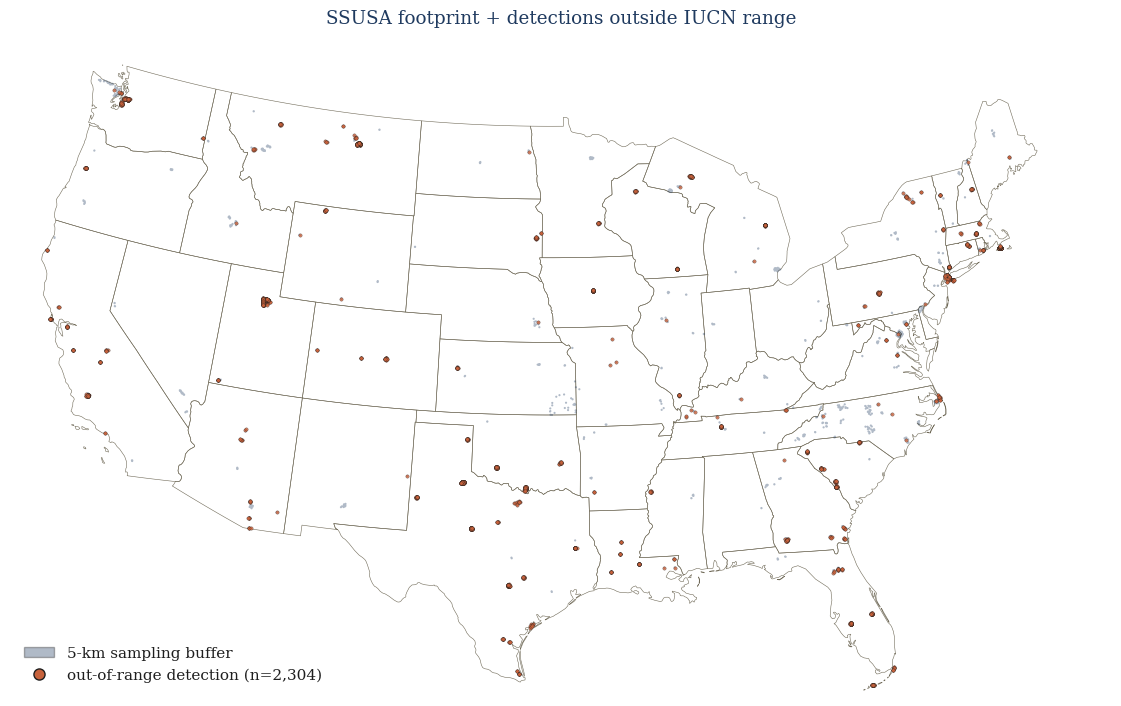

In [18]:
# H3 = H1 + H2 overlaid (skip the aggregate IUCN union — 733 polygons
# across species have topology issues; the other two layers already tell
# the combined "sampling footprint + out-of-range" story).

fig, ax = plt.subplots()
draw_us_basemap(ax, lw=0.4)
buffer_gdf.plot(ax=ax, facecolor=INDIGO, edgecolor=INDIGO,
                linewidth=0.0, alpha=0.35, zorder=1)
out_of_range.plot(ax=ax, color=TERRACOTTA, markersize=6,
                  edgecolor=IRON, linewidth=0.2, alpha=0.80, zorder=3)
_strip_map_axes(ax)
ax.set_title("SSUSA footprint + detections outside IUCN range",
             color=INDIGO, pad=10)
legend_elts = [
    Patch(facecolor=INDIGO, edgecolor=IRON, alpha=0.35,
          label="5-km sampling buffer"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=TERRACOTTA,
           markeredgecolor=IRON, markersize=8,
           label=f"out-of-range detection (n={len(out_of_range):,})"),
]
ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
          loc="lower left", fontsize=11)
savefig_slot(fig, "hero", "H3_hero_combined")
plt.show()


## H4 — HERO variant D · Species raw-data drill-down (zoomed to polygon)
Dr. Mussmann's suggestion: pick ONE species, show its IUCN polygon, draw every camera the 1-km footprint places inside that polygon, and colour them filled (**species detected**) vs. hollow (**predicted · not detected**). Four variants — Elk · Moose · Black bear · White-tailed deer — so the team can A/B which species reads best on the poster.

  saved H4a_hero_elk_rawdata: hero slot 11.1x8.1in


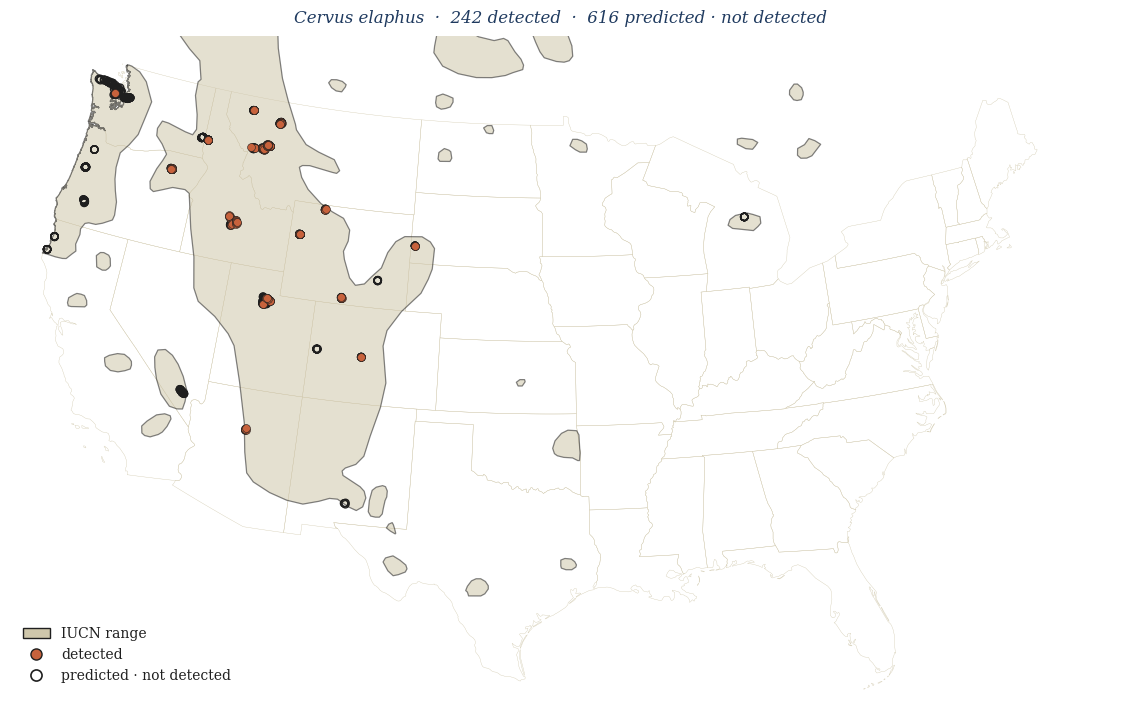

  saved H4b_hero_moose_rawdata: hero slot 11.1x8.1in


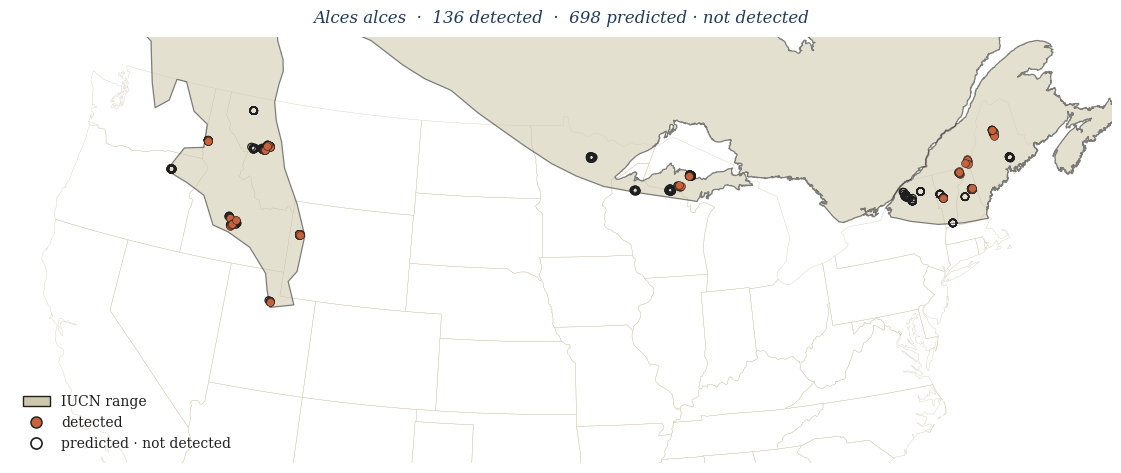

  saved H4c_hero_blackbear_rawdata: hero slot 11.1x8.1in


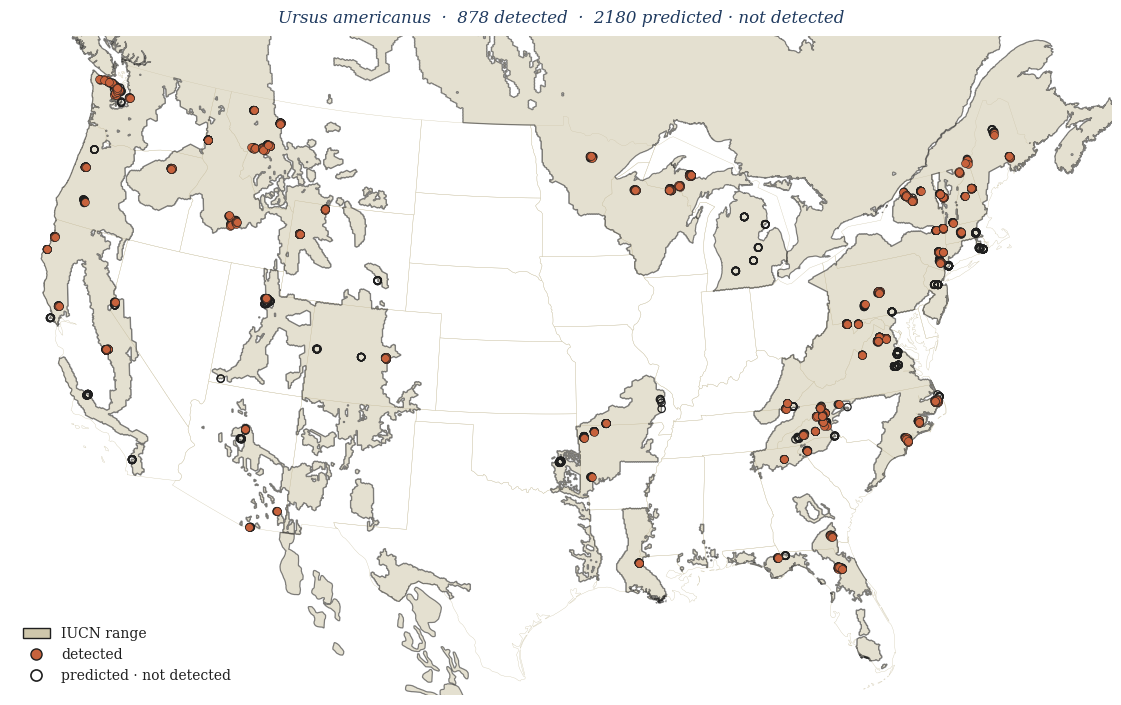

  saved H4d_hero_wtdeer_rawdata: hero slot 11.1x8.1in


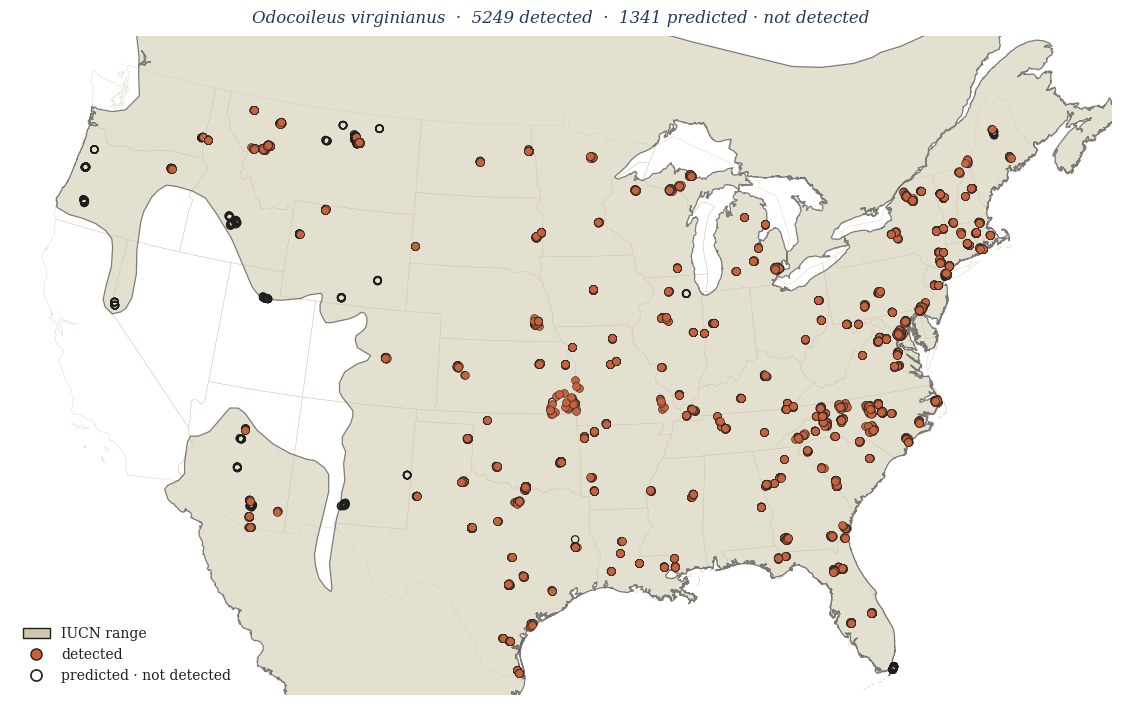

  saved H4e_hero_raccoon_rawdata: hero slot 11.1x8.1in


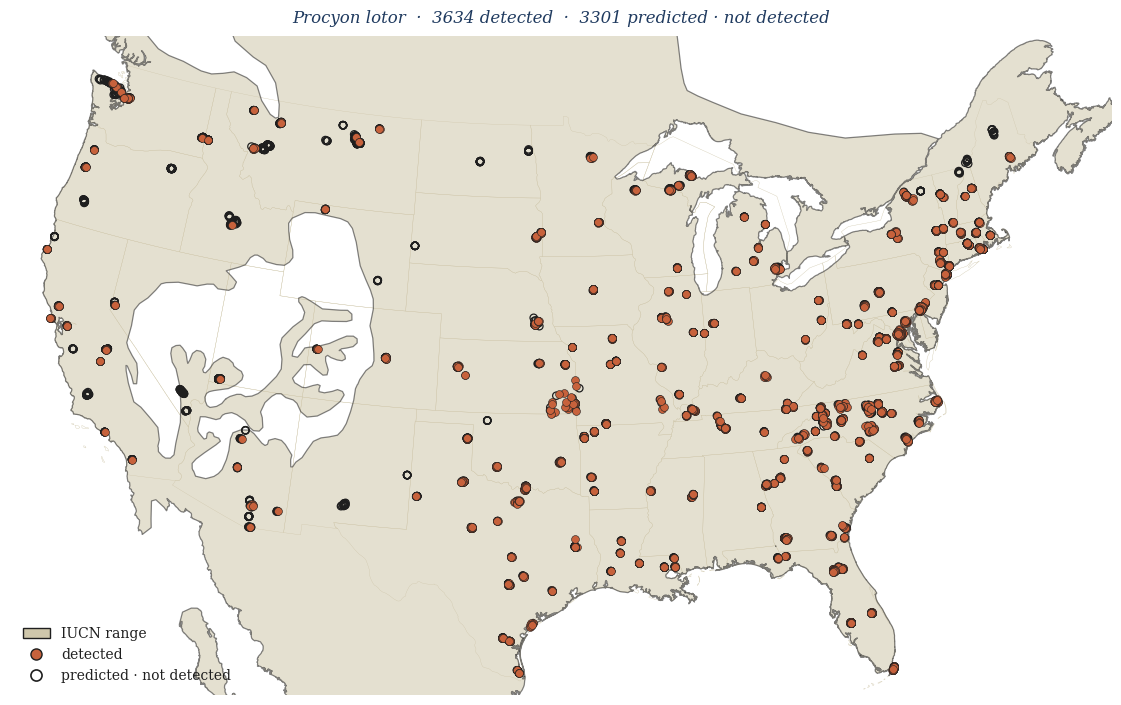

In [19]:
def render_species_hero(sci_name: str, out_name: str, common_name: str):
    """Hero-slot raw-data drill-down for one species.

    Zooms to the IUCN polygon, draws every in-range camera (from the 1-km
    footprint spatial join) as filled (detected) or hollow (missed), and
    reserves a dashed inset for a camera-trap cutout.
    """
    poly = iucn_shp[iucn_shp["sci_name"].str.lower() == sci_name.lower()]
    if poly.empty:
        print(f"  SKIP {sci_name}: no IUCN polygon")
        return

    pred_cam_ids = set(iucn_camera_lk.loc[
        (iucn_camera_lk["sci_name"].str.lower() == sci_name.lower()) &
        (iucn_camera_lk["ab_thres"] == True),
        "camera_fp_id"
    ])
    cam_pts = camera_fp.copy()
    cam_pts["geometry"] = cam_pts.geometry.centroid
    pred_in_poly = cam_pts[cam_pts["camera_fp_id"].isin(pred_cam_ids)].copy()

    det_xy = set(zip(
        ssusa_mass.loc[ssusa_mass["Species_Name"].str.lower() == sci_name.lower(),
                       "Longitude"].round(5),
        ssusa_mass.loc[ssusa_mass["Species_Name"].str.lower() == sci_name.lower(),
                       "Latitude"].round(5),
    ))
    is_det = pred_in_poly.apply(
        lambda r: (round(r["Longitude"], 5), round(r["Latitude"], 5)) in det_xy,
        axis=1,
    ) if len(pred_in_poly) else pd.Series([], dtype=bool)
    detected_in_poly = pred_in_poly[is_det]
    missed_in_poly   = pred_in_poly[~is_det] if len(pred_in_poly) else pred_in_poly

    minx, miny, maxx, maxy = poly.to_crs("EPSG:5070").total_bounds
    pad = 0.05 * max(maxx - minx, maxy - miny)
    xlim = (max(CONUS_XLIM[0], minx - pad), min(CONUS_XLIM[1], maxx + pad))
    ylim = (max(CONUS_YLIM[0], miny - pad), min(CONUS_YLIM[1], maxy + pad))

    fig, ax = plt.subplots()
    draw_us_basemap(ax, lw=0.25, edge=FOG)
    poly.plot(ax=ax, facecolor=FOG, edgecolor=IRON, linewidth=0.9,
              alpha=0.55, zorder=2)
    if len(missed_in_poly):
        ax.scatter(missed_in_poly.geometry.x, missed_in_poly.geometry.y,
                   facecolors="none", edgecolors=IRON, linewidth=0.9,
                   s=28, zorder=3)
    if len(detected_in_poly):
        ax.scatter(detected_in_poly.geometry.x, detected_in_poly.geometry.y,
                   facecolors=TERRACOTTA, edgecolors=IRON, linewidth=0.4,
                   s=32, zorder=4)

    _strip_map_axes(ax)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    ax.set_title(
        f"{sci_name}  ·  {len(detected_in_poly)} detected  ·  "
        f"{len(missed_in_poly)} predicted · not detected",
        color=INDIGO, fontsize=12, style="italic", pad=10,
    )

    legend_elts = [
        Patch(facecolor=FOG, edgecolor=IRON, label="IUCN range"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=TERRACOTTA,
               markeredgecolor=IRON, markersize=8, label="detected"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
               markeredgecolor=IRON, markeredgewidth=1.2, markersize=8,
               label="predicted · not detected"),
    ]
    ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
              loc="lower left", fontsize=10)

    savefig_slot(fig, "hero", out_name)
    plt.show()


render_species_hero("Cervus elaphus",      "H4a_hero_elk_rawdata",       "Elk")
render_species_hero("Alces alces",            "H4b_hero_moose_rawdata",     "Moose")
render_species_hero("Ursus americanus",       "H4c_hero_blackbear_rawdata", "Black bear")
render_species_hero("Odocoileus virginianus", "H4d_hero_wtdeer_rawdata",    "White-tailed deer")
render_species_hero("Procyon lotor",           "H4e_hero_raccoon_rawdata",   "Raccoon")


## H5 — HERO variant E · North American porcupine (in- AND out-of-range)
Porcupine (*Erethizon dorsatum*) is a clean example of a species detected **both inside** its IUCN polygon AND **outside** of it. Same helper as H4 but adds a third marker class for out-of-range detections, and the zoom encompasses both polygon and outlier detections.

  saved H5_hero_porcupine_in_and_out: hero slot 11.1x8.1in


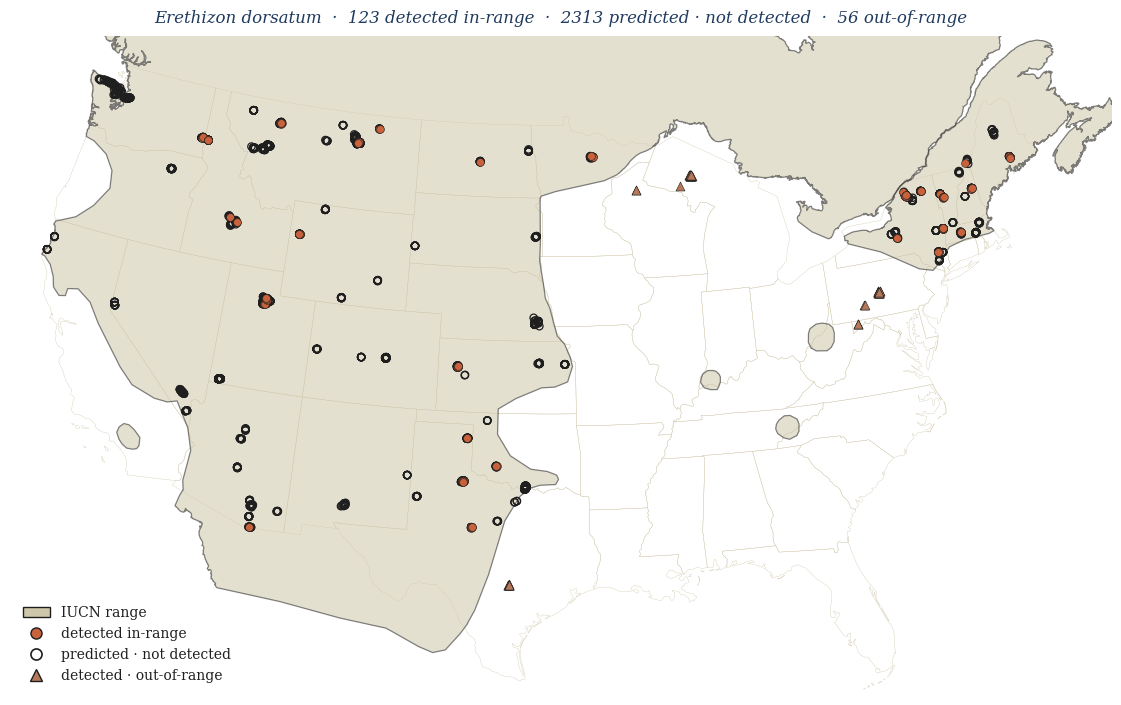

In [20]:
def render_species_hero_with_outrange(sci_name, out_name, common_name):
    """Hero map: polygon + in-range detected/missed + out-of-range detections."""
    poly = iucn_shp[iucn_shp["sci_name"].str.lower() == sci_name.lower()]
    if poly.empty:
        print(f"  SKIP {sci_name}: no IUCN polygon"); return

    # Predicted-in-range cameras (1-km footprint join)
    pred_cam_ids = set(iucn_camera_lk.loc[
        (iucn_camera_lk["sci_name"].str.lower() == sci_name.lower()) &
        (iucn_camera_lk["ab_thres"] == True), "camera_fp_id"])
    cam_pts = camera_fp.copy()
    cam_pts["geometry"] = cam_pts.geometry.centroid
    pred_in_poly = cam_pts[cam_pts["camera_fp_id"].isin(pred_cam_ids)].copy()

    # All SSUSA detections of this species (above threshold)
    det = (ssusa_mass.loc[ssusa_mass["Species_Name"].str.lower() == sci_name.lower(),
                          ["Latitude", "Longitude"]].drop_duplicates())
    det_xy = set(zip(det["Longitude"].round(5), det["Latitude"].round(5)))
    det_gdf = gpd.GeoDataFrame(
        det, geometry=gpd.points_from_xy(det["Longitude"], det["Latitude"]),
        crs="EPSG:4326").to_crs("EPSG:5070")

    # In-range cameras: filled if detected, hollow if predicted-only
    is_det = pred_in_poly.apply(
        lambda r: (round(r["Longitude"], 5), round(r["Latitude"], 5)) in det_xy,
        axis=1) if len(pred_in_poly) else pd.Series([], dtype=bool)
    detected_in_poly = pred_in_poly[is_det]
    missed_in_poly   = pred_in_poly[~is_det] if len(pred_in_poly) else pred_in_poly

    # Out-of-range detections: any detection point NOT inside the polygon
    poly_union = poly.to_crs("EPSG:5070").geometry.union_all()
    inside_mask = det_gdf.geometry.within(poly_union)
    out_of_range = det_gdf[~inside_mask]

    # Zoom to the UNION of polygon + all detections (so outliers are visible)
    minx_p, miny_p, maxx_p, maxy_p = poly.to_crs("EPSG:5070").total_bounds
    if len(det_gdf):
        minx_d, miny_d, maxx_d, maxy_d = det_gdf.total_bounds
        minx, miny = min(minx_p, minx_d), min(miny_p, miny_d)
        maxx, maxy = max(maxx_p, maxx_d), max(maxy_p, maxy_d)
    else:
        minx, miny, maxx, maxy = minx_p, miny_p, maxx_p, maxy_p
    pad = 0.05 * max(maxx - minx, maxy - miny)
    xlim = (max(CONUS_XLIM[0], minx - pad), min(CONUS_XLIM[1], maxx + pad))
    ylim = (max(CONUS_YLIM[0], miny - pad), min(CONUS_YLIM[1], maxy + pad))

    fig, ax = plt.subplots()
    draw_us_basemap(ax, lw=0.25, edge=FOG)
    poly.plot(ax=ax, facecolor=FOG, edgecolor=IRON, linewidth=0.9,
              alpha=0.55, zorder=2)
    if len(missed_in_poly):
        ax.scatter(missed_in_poly.geometry.x, missed_in_poly.geometry.y,
                   facecolors="none", edgecolors=IRON, linewidth=0.9,
                   s=28, zorder=3)
    if len(detected_in_poly):
        ax.scatter(detected_in_poly.geometry.x, detected_in_poly.geometry.y,
                   facecolors=TERRACOTTA, edgecolors=IRON, linewidth=0.4,
                   s=32, zorder=4)
    if len(out_of_range):
        ax.scatter(out_of_range.geometry.x, out_of_range.geometry.y,
                   marker="^", facecolors=CLAY, edgecolors=IRON, linewidth=0.4,
                   s=42, zorder=5)

    _strip_map_axes(ax)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    ax.set_title(
        f"{sci_name}  ·  {len(detected_in_poly)} detected in-range  ·  "
        f"{len(missed_in_poly)} predicted · not detected  ·  "
        f"{len(out_of_range)} out-of-range",
        color=INDIGO, fontsize=12, style="italic", pad=10,
    )

    legend_elts = [
        Patch(facecolor=FOG, edgecolor=IRON, label="IUCN range"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=TERRACOTTA,
               markeredgecolor=IRON, markersize=8, label="detected in-range"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
               markeredgecolor=IRON, markeredgewidth=1.2, markersize=8,
               label="predicted · not detected"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor=CLAY,
               markeredgecolor=IRON, markersize=9, label="detected · out-of-range"),
    ]
    ax.legend(handles=legend_elts, frameon=False, labelcolor=IRON,
              loc="lower left", fontsize=10)

    savefig_slot(fig, "hero", out_name)
    plt.show()


render_species_hero_with_outrange(
    "Erethizon dorsatum", "H5_hero_porcupine_in_and_out", "North American porcupine")


## B1 — Box B variant A · Array-level Jaccard vs survey-nights

  saved B1_boxB_jaccard_effort_array: boxB slot 6.37x4.9in


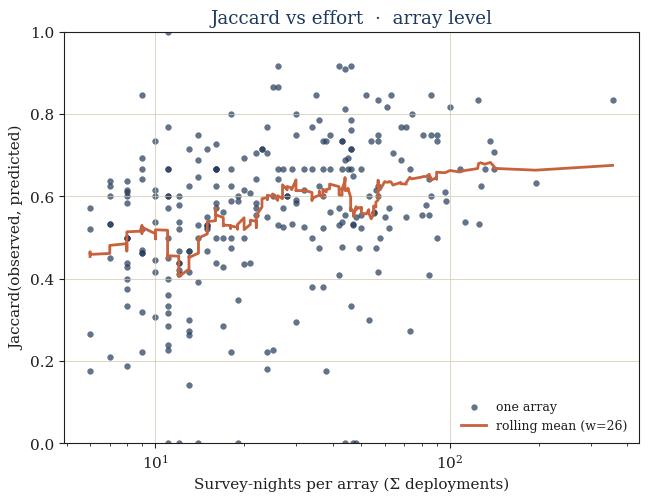

In [21]:
fig, ax = plt.subplots()
d = array_jaccard.dropna().sort_values("array_nights")
ax.scatter(d["array_nights"], d["jaccard"], color=INDIGO, s=18, alpha=0.7,
           edgecolor=IRON, linewidth=0.2, label="one array")

# Rolling mean
if len(d) >= 15:
    window = max(15, len(d) // 10)
    roll = d["jaccard"].rolling(window, center=True, min_periods=5).mean()
    ax.plot(d["array_nights"], roll, color=TERRACOTTA, linewidth=2.0,
            label=f"rolling mean (w={window})")
ax.set_xlabel("Survey-nights per array (Σ deployments)", color=IRON)
ax.set_ylabel("Jaccard(observed, predicted)", color=IRON)
ax.set_title("Jaccard vs effort  ·  array level", color=INDIGO)
ax.set_ylim(0, 1.0)
ax.set_xscale("log")
ax.legend(frameon=False, labelcolor=IRON, fontsize=9, loc="lower right")
savefig_slot(fig, "boxB", "B1_boxB_jaccard_effort_array")
plt.show()


## B2 — Box B variant B · Camera-level Jaccard vs survey-nights

  saved B2_boxB_jaccard_effort_camera: boxB slot 6.37x4.9in


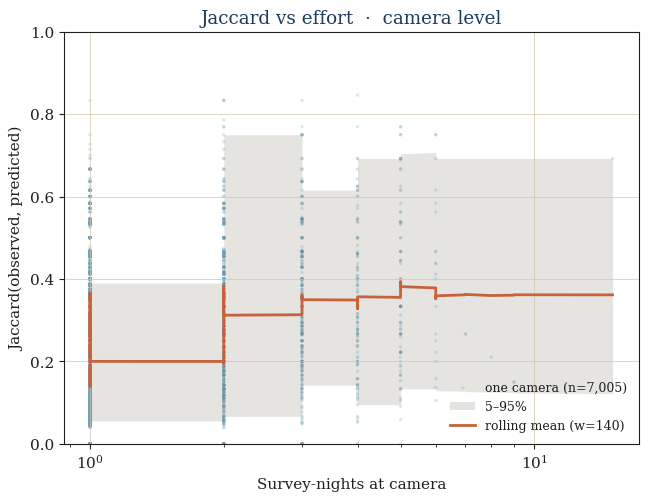

In [22]:
fig, ax = plt.subplots()
d = camera_compare.dropna(subset=["jaccard_index", "unique_nights"]).sort_values("unique_nights")
ax.scatter(d["unique_nights"], d["jaccard_index"], color=SKY, s=6, alpha=0.25,
           edgecolor="none", label=f"one camera (n={len(d):,})")

# Rolling mean + quantile band on sorted x
if len(d) >= 50:
    window = max(50, len(d) // 50)
    roll_mean = d["jaccard_index"].rolling(window, center=True, min_periods=20).mean()
    roll_lo = d["jaccard_index"].rolling(window, center=True, min_periods=20).quantile(0.05)
    roll_hi = d["jaccard_index"].rolling(window, center=True, min_periods=20).quantile(0.95)
    ax.fill_between(d["unique_nights"], roll_lo, roll_hi,
                    color=STONE, alpha=0.18, linewidth=0, label="5–95%")
    ax.plot(d["unique_nights"], roll_mean, color=TERRACOTTA, linewidth=2.0,
            label=f"rolling mean (w={window})")
ax.set_xlabel("Survey-nights at camera", color=IRON)
ax.set_ylabel("Jaccard(observed, predicted)", color=IRON)
ax.set_title("Jaccard vs effort  ·  camera level", color=INDIGO)
ax.set_ylim(0, 1.0)
ax.set_xscale("log")
ax.legend(frameon=False, labelcolor=IRON, fontsize=9, loc="lower right")
savefig_slot(fig, "boxB", "B2_boxB_jaccard_effort_camera")
plt.show()


## B3 — Box B variant C · Dual panel (array + camera)

  saved B3_boxB_jaccard_effort_dual: boxB slot 6.37x4.9in


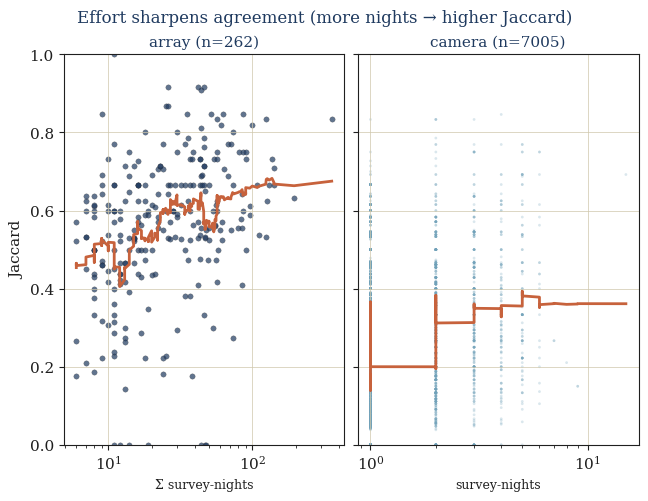

In [23]:
fig, (axL, axR) = plt.subplots(1, 2, sharey=True, constrained_layout=True)

# Array
d = array_jaccard.dropna().sort_values("array_nights")
axL.scatter(d["array_nights"], d["jaccard"], color=INDIGO, s=15, alpha=0.7,
            edgecolor=IRON, linewidth=0.2)
if len(d) >= 15:
    window = max(15, len(d) // 10)
    roll = d["jaccard"].rolling(window, center=True, min_periods=5).mean()
    axL.plot(d["array_nights"], roll, color=TERRACOTTA, linewidth=2.0)
axL.set_xscale("log")
axL.set_title("array (n=%d)" % len(d), color=INDIGO, fontsize=11)
axL.set_xlabel("Σ survey-nights", color=IRON, fontsize=9)
axL.set_ylabel("Jaccard", color=IRON)
axL.set_ylim(0, 1.0)

# Camera
dc = camera_compare.dropna(subset=["jaccard_index", "unique_nights"]).sort_values("unique_nights")
axR.scatter(dc["unique_nights"], dc["jaccard_index"], color=SKY, s=4, alpha=0.25,
            edgecolor="none")
if len(dc) >= 50:
    window = max(50, len(dc) // 50)
    roll_mean = dc["jaccard_index"].rolling(window, center=True, min_periods=20).mean()
    axR.plot(dc["unique_nights"], roll_mean, color=TERRACOTTA, linewidth=2.0)
axR.set_xscale("log")
axR.set_title("camera (n=%d)" % len(dc), color=INDIGO, fontsize=11)
axR.set_xlabel("survey-nights", color=IRON, fontsize=9)

fig.suptitle("Effort sharpens agreement (more nights → higher Jaccard)",
             color=INDIGO, fontsize=12)
savefig_slot(fig, "boxB", "B3_boxB_jaccard_effort_dual")
plt.show()


## C1 — Box C headline · Per-habitat Jaccard-effort curves

  saved C1_boxC_jaccard_effort_by_habitat: boxC slot 7.85x2.75in


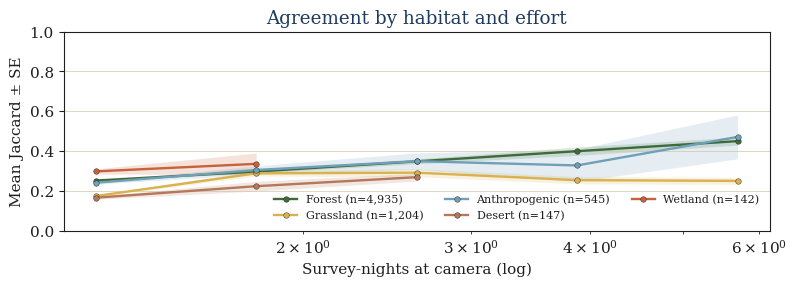

In [24]:
fig, ax = plt.subplots()

# Attach habitat + array-nights onto camera_compare (already has Habitat)
# Bin cameras by unique_nights into log-spaced bins, compute mean Jaccard per habitat
cc = camera_compare.dropna(subset=["jaccard_index", "unique_nights", "Habitat"])
top_hab = cc["Habitat"].value_counts().head(5).index.tolist()
bins = np.geomspace(1, max(cc["unique_nights"].max(), 2), 8)
bin_centers = np.sqrt(bins[:-1] * bins[1:])

palette_cycle = [FOREST, STRAW, SKY, CLAY, TERRACOTTA]
for hab, color in zip(top_hab, palette_cycle):
    sub = cc[cc["Habitat"] == hab].copy()
    sub["bin"] = pd.cut(sub["unique_nights"], bins, labels=False, include_lowest=True)
    grp = sub.groupby("bin")["jaccard_index"].agg(["mean", "sem", "count"])
    grp = grp[grp["count"] >= 5]
    if grp.empty: continue
    xs = bin_centers[grp.index.astype(int)]
    ax.fill_between(xs, grp["mean"] - grp["sem"], grp["mean"] + grp["sem"],
                    color=color, alpha=0.18, linewidth=0)
    ax.plot(xs, grp["mean"], color=color, marker="o", markersize=4,
            linewidth=1.7, label=f"{hab} (n={len(sub):,})",
            markeredgecolor=IRON, markeredgewidth=0.3)

ax.set_xscale("log")
ax.set_xlabel("Survey-nights at camera (log)", color=IRON)
ax.set_ylabel("Mean Jaccard ± SE", color=IRON)
ax.set_title("Agreement by habitat and effort", color=INDIGO)
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, labelcolor=IRON, fontsize=8, ncol=3, loc="lower right")
savefig_slot(fig, "boxC", "C1_boxC_jaccard_effort_by_habitat")
plt.show()


## S1 — Supporting · Random-Forest feature importance
NLCD/roads data (`Annual_NLCD_LndCov_2024_CU_C1V1.tif`) is not in the current repo, so this uses the SSUSA-only feature set (effort + habitat + development + feature_type). Dual panel splits: left = survey effort (only continuous numeric feature `unique_nights`) and location; right = habitat/development/feature-type dummies. Target = camera-level Jaccard.

RF test R^2 = 0.466  (n_train=5,253, n_test=1,752)
Longitude                     0.516244
Latitude                      0.344416
unique_nights                 0.078309
Development_Level_Suburban    0.019395
Development_Level_Wild        0.010296
Development_Level_Rural       0.007077
Development_Level_Urban       0.006376
Habitat_Shrubland             0.004702
Habitat_Forest                0.004568
Habitat_Grassland             0.003330
Habitat_Wetland               0.002851
Habitat_Anthropogenic         0.002080
Habitat_Desert                0.000314
Habitat_Chaparral             0.000039
Habitat_Beach                 0.000002
dtype: float64


  saved S1_supporting_rf_importance: supporting slot 10.5x3.4in


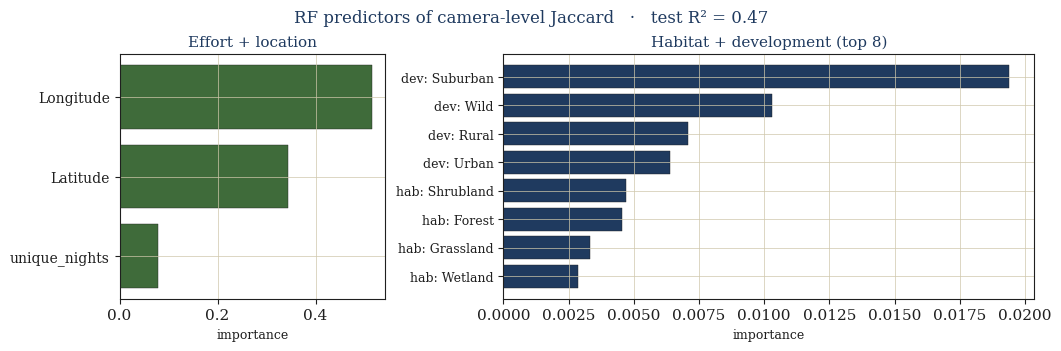

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

rf_df = camera_compare.dropna(subset=["jaccard_index", "unique_nights"]).copy()
# One-hot encode the categorical columns
cat_cols = ["Habitat", "Development_Level"]
for c in cat_cols:
    rf_df[c] = rf_df[c].fillna("Unknown").astype(str)

X_cat = pd.get_dummies(rf_df[cat_cols], prefix=cat_cols)
X_num = rf_df[["unique_nights", "Latitude", "Longitude"]].astype(float)
X = pd.concat([X_num, X_cat.astype(int)], axis=1)
y = rf_df["jaccard_index"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=20260512)
rf = RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=20260512,
                           max_depth=None, min_samples_leaf=3)
rf.fit(X_train, y_train)
r2 = r2_score(y_test, rf.predict(X_test))
print(f"RF test R^2 = {r2:.3f}  (n_train={len(X_train):,}, n_test={len(X_test):,})")

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.head(15))

# Split features into two groups for dual panel
LOC_FEAT = {"unique_nights", "Latitude", "Longitude"}
env_feats = [f for f in imp.index if f in LOC_FEAT]
cat_feats_all = [f for f in imp.index if f not in LOC_FEAT]
cat_feats = imp[cat_feats_all].head(8).index.tolist()  # top 8

fig, (axL, axR) = plt.subplots(1, 2, constrained_layout=True,
                               gridspec_kw={"width_ratios": [1, 2]})

# Left panel - effort + location
vals_L = imp[env_feats][::-1]
axL.barh(range(len(vals_L)), vals_L.values, color=FOREST,
         edgecolor=IRON, linewidth=0.3)
axL.set_yticks(range(len(vals_L)))
axL.set_yticklabels(vals_L.index, color=IRON, fontsize=10)
axL.set_title("Effort + location", color=INDIGO, fontsize=11)
axL.set_xlabel("importance", color=IRON, fontsize=9)

# Right panel - categorical
vals_R = imp[cat_feats][::-1]
axR.barh(range(len(vals_R)), vals_R.values, color=INDIGO,
         edgecolor=IRON, linewidth=0.3)
axR.set_yticks(range(len(vals_R)))
# Shorten labels
short_labels = [lbl.replace("Habitat_", "hab: ")
                .replace("Development_Level_", "dev: ")
                .replace("_", " ") for lbl in vals_R.index]
axR.set_yticklabels(short_labels, color=IRON, fontsize=9)
axR.set_title("Habitat + development (top 8)", color=INDIGO, fontsize=11)
axR.set_xlabel("importance", color=IRON, fontsize=9)

fig.suptitle(f"RF predictors of camera-level Jaccard   ·   test R² = {r2:.2f}",
             color=INDIGO, fontsize=12)
savefig_slot(fig, "supporting", "S1_supporting_rf_importance")
plt.show()


## Verification
SVG validity + transparent-background + dimension checks.

In [26]:
import xml.etree.ElementTree as ET

svgs = sorted(SVG_DIR.glob("*.svg"))
print(f"{len(svgs)} SVGs written:")
for svg in svgs:
    tree = ET.parse(svg)
    root = tree.getroot()
    w = root.get("width"); h = root.get("height")
    has_embedded_raster = any(
        elt.tag.endswith("image") for elt in root.iter())
    print(f"  {svg.name:45s}  {w} x {h}  raster={has_embedded_raster}")

print()
print(f"PNG fallbacks: {len(list(PNG_DIR.glob('*.png')))}")
print(f"mpl.rcParams['svg.fonttype'] = {mpl.rcParams['svg.fonttype']!r}")
print("Palette locked to Field Guide tokens only.")


24 SVGs written:
  B1_boxB_jaccard_effort_array.svg               458.64pt x 352.8pt  raster=False
  B2_boxB_jaccard_effort_camera.svg              458.64pt x 352.8pt  raster=False
  B3_boxB_jaccard_effort_dual.svg                458.64pt x 352.8pt  raster=False
  C1_boxC_jaccard_effort_by_habitat.svg          565.2pt x 198pt  raster=False
  H1_hero_out_of_range.svg                       799.2pt x 583.2pt  raster=False
  H2_hero_buffer_coverage.svg                    799.2pt x 583.2pt  raster=False
  H3_hero_combined.svg                           799.2pt x 583.2pt  raster=False
  H4a_hero_elk_rawdata.svg                       799.2pt x 583.2pt  raster=False


  H4b_hero_moose_rawdata.svg                     799.2pt x 583.2pt  raster=False
  H4c_hero_blackbear_rawdata.svg                 799.2pt x 583.2pt  raster=False
  H4d_hero_wtdeer_rawdata.svg                    799.2pt x 583.2pt  raster=False
  H4e_hero_raccoon_rawdata.svg                   799.2pt x 583.2pt  raster=False


  H5_hero_porcupine_in_and_out.svg               799.2pt x 583.2pt  raster=False
  R1_boxA_sac_iucn_vs_ssusa_500g.svg             458.64pt x 352.8pt  raster=False
  S1_supporting_rf_importance.svg                756pt x 244.8pt  raster=False
  V10_boxC_false_plateau_matrix.svg              565.2pt x 198pt  raster=True
  V11_supporting_jaccard_trajectory.svg          756pt x 244.8pt  raster=False
  V1_hero_agreement_jaccard.svg                  799.2pt x 583.2pt  raster=True


  V2_hero_4panel_comparison.svg                  799.2pt x 583.2pt  raster=True
  V3_supporting_species_scatter.svg              756pt x 244.8pt  raster=False
  V4_supporting_top_discordance.svg              756pt x 244.8pt  raster=False
  V5_fieldplate_flagship_drilldown.svg           345.6pt x 187.2pt  raster=False
  V6_boxA_sac_by_mass.svg                        458.64pt x 352.8pt  raster=False
  V7_boxB_ci_gap_by_effort.svg                   458.64pt x 352.8pt  raster=False

PNG fallbacks: 24
mpl.rcParams['svg.fonttype'] = 'path'
Palette locked to Field Guide tokens only.
